# Detecting Tipping Points with Ammonyte's Augmented KS Test

## Goal
This notebook demonstrates how to use Ammonyte's `kstest()` method to detect abrupt climate transitions in the NGRIP ice core record using the augmented Kolmogorov-Smirnov (KS) test of Bagniewski et al. (2021).

## Scientific Background
**Tipping points** represent **critical transition events** in the climate system where the system rapidly shifts from one stable state to another. These abrupt transitions are fundamental to understanding:
- Past climate variability and stability
- Mechanisms driving abrupt climate change
- Early warning signals for future climate shifts

## Methodology
The primary detection method employed is the **augmented  Kolmogorov-Smirnov (KS) test**, a statistical approach specifically designed for identifying abrupt transitions in paleoclimate records.

## Implementation
The workflow and parameter settings are based on the methodology described in:

**Reference**: [Bagniewski, W., et al. (2021). "Automatic detection of 
abrupt transitions in paleoclimate records." *Chaos* 31, 
113129.](https://doi.org/10.1063/5.0062543)

## Dataset
Analysis will be performed on the **NGRIP (North Greenland Ice Core Project)** dataset, which provides high-resolution $\delta^{18}O$ isotope measurements spanning the last glacial period—ideal for studying
Dansgaard-Oeschger events and other rapid climate transitions.

## Expected Outcomes
- Identification and quantification of abrupt climate transitions
- Statistical characterization of transition timing and magnitude
- Visualization of detected tipping points in the context of paleoclimate variability

## Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import ammonyte as amt
from ammonyte.core.series import Series
from ammonyte.utils.ks import KS_test

## Load the NGRIP Dataset

The **NGRIP (North Greenland Ice Core Project)** dataset contains high-resolution $\delta^{18}O$ isotope measurements spanning the last glacial period. It is used here to demonstrate detection of abrupt climate transitions.

In [2]:
# Load NGRIP dataset using the proper ammonyte data path
ngrip = amt.Series.from_csv('../ammonyte/data/NGRIP.csv')

# Display basic metadata about the dataset
print(f"Loaded NGRIP dataset: {ngrip.label}")
print(f"Time range: {ngrip.time.min():.2f} - {ngrip.time.max():.2f} {ngrip.time_unit}")
print(f"Number of data points: {len(ngrip.time)}")
print(f"Value range: {ngrip.value.min():.2f} - {ngrip.value.max():.2f} {ngrip.value_unit}")

# Show the object
ngrip

Time axis values sorted in ascending order
Time axis values sorted in ascending order
Loaded NGRIP dataset: NGRIP Ice Core Data
Time range: 0.05 - 122.27 kyr b2k
Number of data points: 6112
Value range: -46.50 - -32.11 ‰
{'label': 'NGRIP Ice Core Data'}


None
Age [kyr b2k]
0.05     -35.11
0.07     -34.65
0.09     -34.53
0.11     -35.29
0.13     -35.02
          ...  
122.19   -32.85
122.21   -32.66
122.23   -32.66
122.25   -32.51
122.27   -32.56
Name: δ¹⁸O [‰], Length: 6112, dtype: float64

### Dataset Metadata

In [3]:
print("=== NGRIP DATASET INFO ===")
print(f"Original NGRIP series label: {ngrip.label}")
print(f"Value name: {ngrip.value_name}")
print(f"Value unit: {ngrip.value_unit}")
print(f"Time name: {ngrip.time_name}")
print(f"Time unit: {ngrip.time_unit}")


=== NGRIP DATASET INFO ===
Original NGRIP series label: NGRIP Ice Core Data
Value name: δ¹⁸O
Value unit: ‰
Time name: Age
Time unit: kyr b2k


### NGRIP $\delta^{18}O$ Record
More negative values indicate colder conditions.

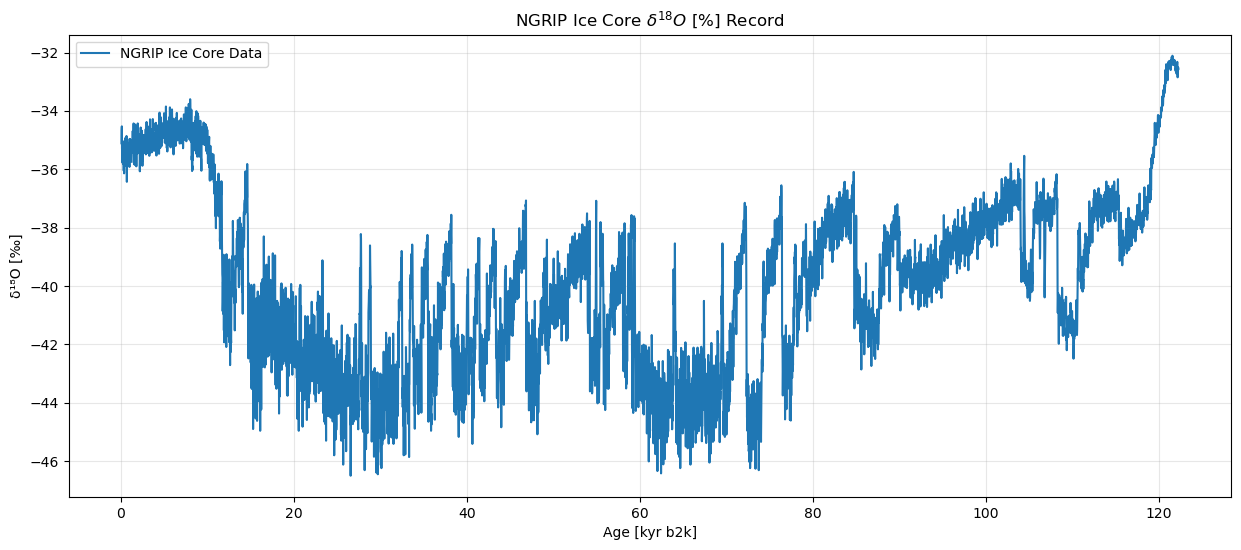

In [4]:
# The NGRIP series is already loaded with proper metadata
#plot the time series to visualize the data
fig, ax = ngrip.plot(figsize=(15, 6))
ax.set_title('NGRIP Ice Core $\delta^{18}O\ [\%]$ Record')
ax.grid(True, alpha=0.3)

## Step 1: Apply KS Test

The augmented KS test scans the time series with sliding windows of varying sizes, comparing statistical distributions on either side of each candidate transition point.

**Parameters (from Bagniewski et al. 2021, optimized for NGRIP):**
- `w_min = 0.12`, `w_max = 2.5`: window size range (kyr)
- `n_w = 15`: number of logarithmically-spaced window sizes
- `d_c = 0.77`: KS statistic threshold
- `n_c = 3`: minimum samples per window half
- `s_c = 2`: standard deviation ratio cutoff
- `x_c = 0.8`: minimum proxy value change (‰)

In [5]:
# Apply KS test — parameters from Bagniewski et al. (2021)
transitions = ngrip.kstest(w_min=0.12, w_max=2.5, n_w=15, d_c=0.77, n_c=3, s_c=2, x_c=0.8)
print(transitions)

Deterministic Transition Detection Results - NGRIP Ice Core Data
+----------+---------------------+----------------+------------------+---------------------+
| Method   |   Total Transitions |   Upward Jumps |   Downward Jumps | Series Label        |
+==========+=====================+================+==================+=====================+
| KS test  |                 104 |             49 |               55 | NGRIP Ice Core Data |
+----------+---------------------+----------------+------------------+---------------------+

Transition Details:
  1. Time: 8.14 kyr b2k, Direction: Upward, d_statistics: 0.4080, p_values: < 1e-8
  2. Time: 8.30 kyr b2k, Direction: Downward, d_statistics: 0.3760, p_values: < 1e-7
  3. Time: 10.20 kyr b2k, Direction: Upward, d_statistics: 0.9203, p_values: < 1e-56
  4. Time: 10.86 kyr b2k, Direction: Upward, d_statistics: 0.9680, p_values: < 1e-65
  5. Time: 11.52 kyr b2k, Direction: Downward, d_statistics: 0.9040, p_values: < 1e-53
  6. Time: 11.68 kyr b2k

## Step 2: Transition Visualization

The NGRIP time series with all detected transitions:
- **Red lines**: upward transitions (warming)
- **Blue lines**: downward transitions (cooling)

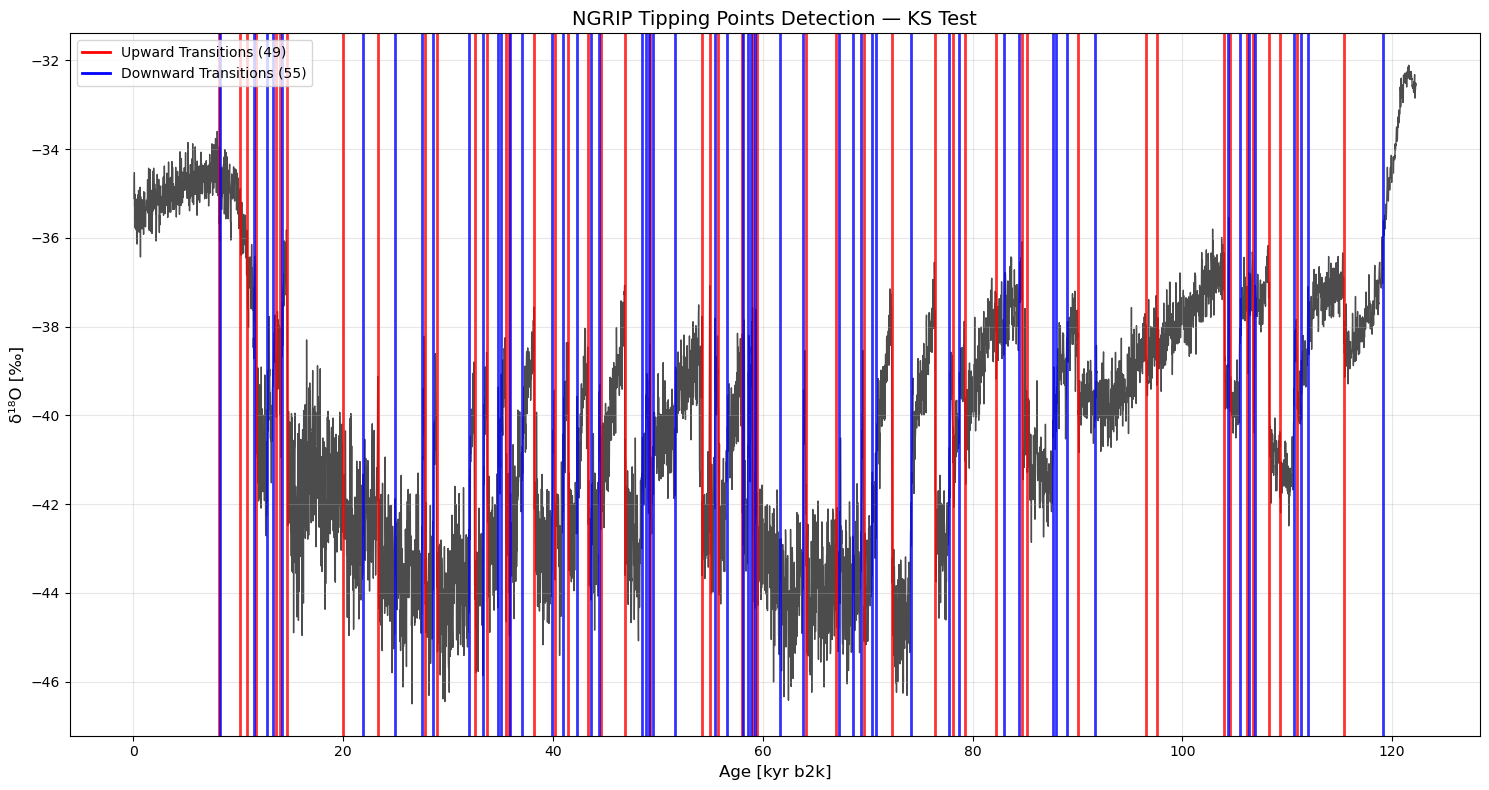

In [6]:
import matplotlib.pyplot as plt

fig, ax = transitions.plot(figsize=(15, 8),
                          title='NGRIP Tipping Points Detection — KS Test',
                          upward_color='red',
                          downward_color='blue')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 3: Load Known DO Events for Validation

To validate our detection results, we compare against published **Dansgaard-Oeschger (DO) events**, documented abrupt warming episodes in the NGRIP record.

**Reference:** [Rasmussen et al. (2014)](https://doi.org/10.1016/j.quascirev.2014.09.007)

In [7]:
do_events = pd.read_csv('../ammonyte/data/DO_events.csv', comment='#')
main_do_events = do_events['main_kyr_b2k'].dropna().values
print(f"Main DO events: {len(main_do_events)}")

Main DO events: 25


## Step 4: Quantitative Validation Against Known DO Events

DO events are abrupt **warming** transitions, so we compare only detected **upward** transitions against the 25 main DO onset times, using a $\pm$ 500-year tolerance window.

In [8]:
# Filter to upward transitions only
upward_mask = transitions.jump_values == 1
detected_upward = transitions.jump_times[upward_mask]
detected_upward = detected_upward[~np.isnan(detected_upward)]

results = amt.utils.evaluate_detection(detected_upward, main_do_events, tolerance=0.5)
print(results)

Detection Evaluation Metrics
Metrics calculated within tolerance = 0.5

Performance Scores:
+-----------+---------+
| Metric    |   Value |
+===========+=========+
| Precision |  0.3878 |
+-----------+---------+
| Recall    |  0.76   |
+-----------+---------+
| F1 Score  |  0.5135 |
+-----------+---------+

Detection Counts:
+-----------------+---------+
| Category        |   Count |
+=================+=========+
| True Positives  |      19 |
+-----------------+---------+
| False Positives |      30 |
+-----------------+---------+
| False Negatives |       6 |
+-----------------+---------+

Summary:
  Detected: 49 | Ground Truth: 25



## Step 5: Validation Visualization

Detected upward transitions vs. known DO events on the NGRIP record:
- **Red lines**: detected upward transitions
- **Green dashed lines**: documented DO warming events (Rasmussen et al., 2014)

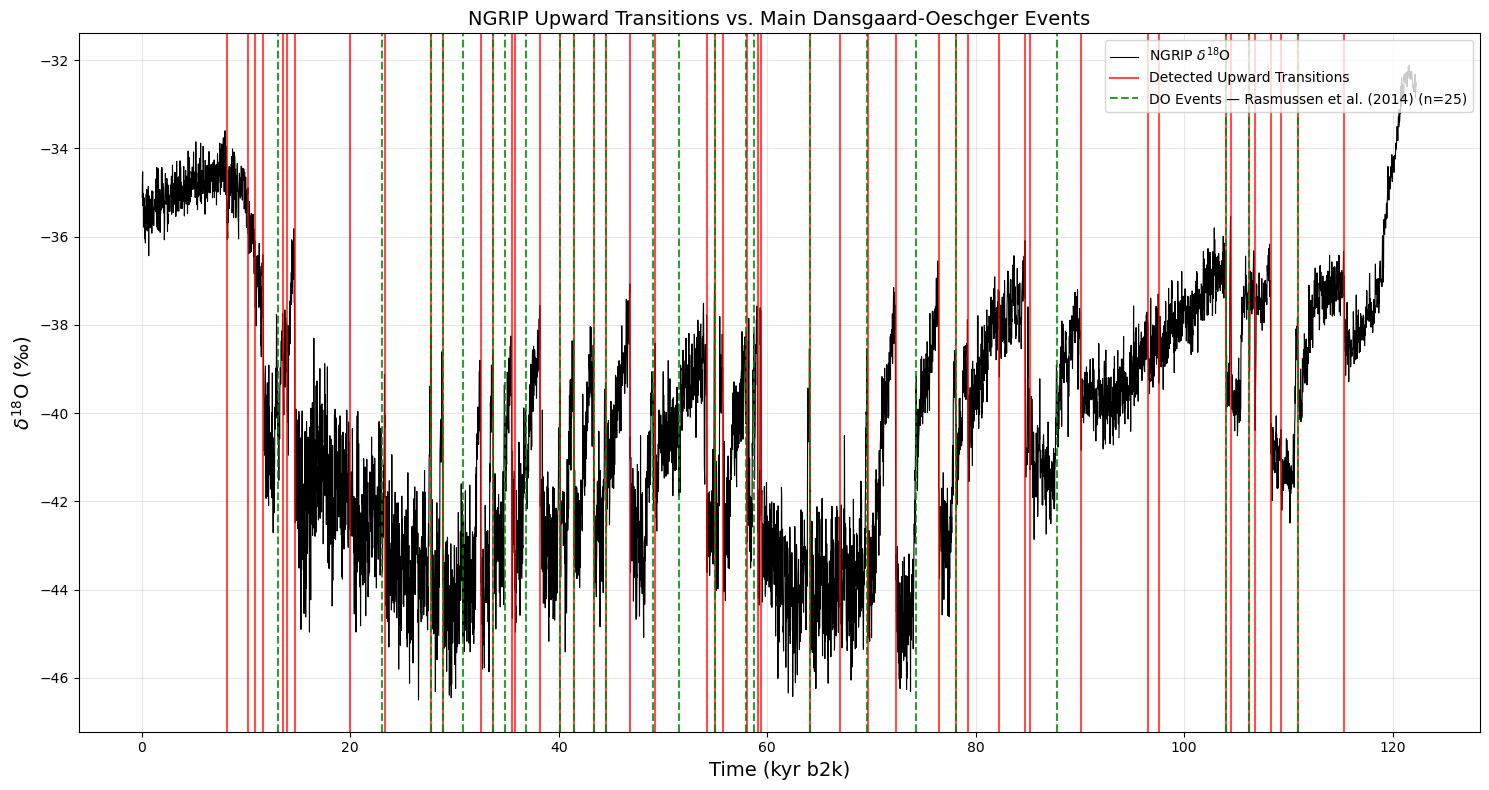

In [9]:
fig, ax = plt.subplots(figsize=(15, 8))
ax.plot(ngrip.time, ngrip.value, color='black', linewidth=0.8, label='NGRIP $\delta^{18}\mathrm{O}$')

first_up = True
for t, direction in zip(transitions.jump_times, transitions.jump_values):
    if direction > 0:
        label = 'Detected Upward Transitions' if first_up else None
        ax.axvline(x=t, color='red', alpha=0.7, linewidth=1.5, label=label)
        first_up = False

for i, event_time in enumerate(main_do_events):
    label = f'DO Events — Rasmussen et al. (2014) (n={len(main_do_events)})' if i == 0 else None
    ax.axvline(event_time, color='green', linestyle='--', linewidth=1.5, alpha=0.8, label=label)

ax.set_xlabel('Time (kyr b2k)', fontsize=14)
ax.set_ylabel('$\delta^{18}\mathrm{O}$ (‰)', fontsize=14)
ax.set_title('NGRIP Upward Transitions vs. Main Dansgaard-Oeschger Events', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusion

We see that the KS test is able to identify **19 of 25 (76%)** of the DO warming events documented by [Rasmussen et al. (2014)](https://doi.org/10.1016/j.quascirev.2014.09.007), with a precision of 39% (F1 = 0.51).

**Pros:** Fast and simple, a single `Series.kstest()` call scans the entire record in seconds. Each detected transition comes with a D-statistic and p-value, making the statistical evidence easy to inspect and report.

**Major drawback:** The KS test only tracks excursions in the *distribution of values*. It says nothing about the dynamics, if the climate shifts state in phase space without a large amplitude change, the KS test will miss it. For dynamically-sensitive detection, see the [LERM tutorial](LERM_validation.ipynb).

For the original method, see [Bagniewski et al. (2021)](https://doi.org/10.1063/5.0062543).